In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/f1_pit_strategy/data/raw/"

lap_times = pd.read_csv(base_path + "lap_times.csv")
pit_stops = pd.read_csv(base_path + "pit_stops.csv")
races = pd.read_csv(base_path + "races.csv")
circuits = pd.read_csv(base_path + "circuits.csv")


Mounted at /content/drive


In [ ]:
races[['raceId', 'year', 'name']].sort_values(['year'], ascending=False).head(10)


,raceId,year,name
1115,1135,2024,Dutch Grand Prix
1116,1136,2024,Italian Grand Prix
1117,1137,2024,Azerbaijan Grand Prix
1118,1138,2024,Singapore Grand Prix
1119,1139,2024,United States Grand Prix
1120,1140,2024,Mexico City Grand Prix
1121,1141,2024,São Paulo Grand Prix
1122,1142,2024,Las Vegas Grand Prix
1123,1143,2024,Qatar Grand Prix
1105,1125,2024,Chinese Grand Prix


In [ ]:
race_id = 1135
race_laps = lap_times[lap_times['raceId'] == race_id]
race_pits = pit_stops[pit_stops['raceId'] == race_id]
race_laps.head()

,raceId,driverId,lap,position,time,milliseconds
578185,1135,830,1,1,1:19.915,79915
578186,1135,830,2,1,1:16.106,76106
578187,1135,830,3,1,1:16.131,76131
578188,1135,830,4,1,1:16.432,76432
578189,1135,830,5,1,1:16.181,76181


In [ ]:
race_laps['driverId'].value_counts().head()


,count
driverId,
830,72
846,72
847,72
857,72
844,72


In [ ]:
driver_id = race_laps['driverId'].value_counts().idxmax()

driver_laps = race_laps[race_laps['driverId'] == driver_id]
driver_pits = race_pits[race_pits['driverId'] == driver_id]
driver_pits.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
11073,1135,830,1,27,15:37:39,20.785,20785


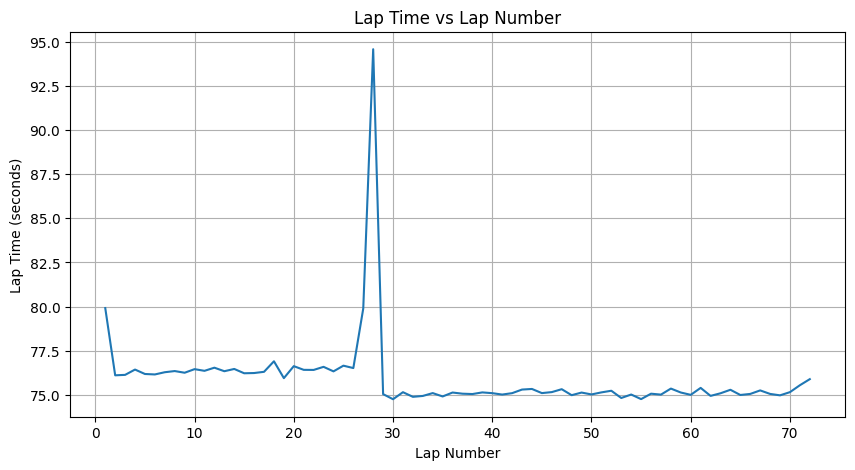

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(driver_laps['lap'], driver_laps['milliseconds'] / 1000)
plt.xlabel("Lap Number")
plt.ylabel("Lap Time in seconds")
plt.title("Lap Time vs Lap Number")
plt.grid(True)
plt.show()


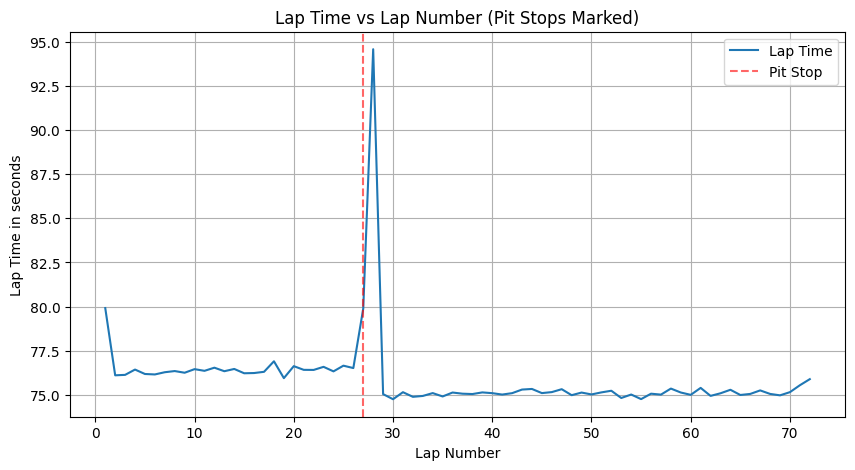

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(driver_laps['lap'], driver_laps['milliseconds'] / 1000, label='Lap Time')

for lap in driver_pits['lap']:
    plt.axvline(x=lap,color='red',linestyle='--',alpha=0.6,label='Pit Stop' if lap == driver_pits['lap'].iloc[0] else "")

plt.xlabel("Lap Number")
plt.ylabel("Lap Time in seconds")
plt.title("Lap Time vs Lap Number (Pit Stops Marked)")
plt.legend()
plt.grid(True)
plt.show()

